In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
X_train_old = pd.read_csv("../data/processed/X_train.csv")
X_test_old = pd.read_csv("../data/processed/X_test.csv")
y_train_old = pd.read_csv("../data/processed/y_train.csv")
y_test_old = pd.read_csv("../data/processed/y_test.csv")

In [5]:
print(X_train_old.shape)
print(X_test_old.shape)


(28846, 33)
(4410, 33)


# Manual Model

In [23]:
class LogisticRegressionManual:
    def __init__(self, learning_rate, epoch, random_state=42):
        self.learning_rate = learning_rate
        self.epoch = epoch
        self.random_state = random_state
        self.cost_history = []
        self.weight = None
        self.bias = None

    def sigmoid(self, z):
        return 1/(1+np.exp(-z))

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).ravel()
        
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        self.weight = np.zeros(n_features)
        self.bias = 0

        for i in range(self.epoch):
            z= X @ self.weight + self.bias
            y_pred = self.sigmoid(z)
            error = y_pred - y
            eps = 1e-15
            y_pred_clip = np.clip(y_pred, eps, 1 - eps)
            cost = -(y *(np.log(y_pred_clip))+(1-y)*np.log(1-y_pred_clip))
            self.cost_history.append(np.mean(cost))

            dw = (1/n_samples)*(X.T @ error)
            db = (1/n_samples)*(np.sum(error))

            self.weight -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            y_label = (y_pred >= 0.5).astype(int)
            acc = np.mean(y_label == y)

            if i % 200 == 0:
                print("W min/max:", np.min(self.weight), np.max(self.weight))
    
            if i%100==0:
                print(f"Epoch {i:4d}: Loss={np.mean(cost):.4f}, Accuracy={acc:.4f}")

    def predict(self, X):
        X = np.array(X)
        z = X @ self.weight + self.bias
        y = self.sigmoid(z)
        return (y >= 0.5).astype(int)

    def accuracy_metric(self, y_pred, y_test):
        true_pos = np.sum((y_pred==1) & (y_test==1))
        true_neg = np.sum((y_pred==0) & (y_test==0))
        false_pos = np.sum((y_pred==1) & (y_test==0))
        false_neg = np.sum((y_pred==0) & (y_test==1))
        
        accuracy = (true_pos+true_neg)/(true_pos+true_neg+false_pos+false_neg)
        precision = true_pos/(true_pos+false_pos) if (true_pos+false_pos)!=0 else 0
        recall = true_pos/(true_pos+false_neg) if (true_pos+false_neg)!=0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

        return accuracy, precision, recall, f1

    def learning_curve(self):
        plt.plot(self.cost_history)
        plt.title("Cost History:")
        plt.xlabel("Epoch")
        plt.ylabel("Cost")
        plt.show()

In [24]:
model = LogisticRegressionManual(learning_rate=0.01, epoch=1000)
model.fit(X_train_old, y_train_old)

W min/max: -0.00012737878819045676 0.0006064136768106907
Epoch    0: Loss=0.6931, Accuracy=0.5000
Epoch  100: Loss=0.6860, Accuracy=0.5785
W min/max: -0.01864949031613161 0.09759183306086201
Epoch  200: Loss=0.6820, Accuracy=0.5797
Epoch  300: Loss=0.6795, Accuracy=0.5803
W min/max: -0.02770517837111925 0.15915175895342765
Epoch  400: Loss=0.6780, Accuracy=0.5796
Epoch  500: Loss=0.6771, Accuracy=0.5806
W min/max: -0.03164308197721439 0.19870239699830222
Epoch  600: Loss=0.6765, Accuracy=0.5812
Epoch  700: Loss=0.6761, Accuracy=0.5808
W min/max: -0.03285318239710324 0.22435106019260742
Epoch  800: Loss=0.6758, Accuracy=0.5807
Epoch  900: Loss=0.6756, Accuracy=0.5813


# Trying on Inbuilt model to check accuracy

In [25]:
X_train_old = np.array(X_train_old)
y_train_old = np.array(y_train_old).ravel()

X_test_old = np.array(X_test_old)
y_test_old = np.array(y_test_old).ravel() 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modelm = LogisticRegression(class_weight="balanced")
modelm.fit(X_train_old, y_train_old)
y_predm = modelm.predict(X_test_old)
print(f"Inbuilt Model Accuracy: {accuracy_score(y_test_old, y_predm) * 100:.2f}%")

Inbuilt Model Accuracy: 57.41%


# Confirming accuracy with non-linear model - Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_old, y_train_old)

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
y_pred = clf.predict(X_test_old)
print(classification_report(y_test_old, y_pred))
print("ROC AUC:", roc_auc_score(y_test_old, clf.predict_proba(X_test_old)[:,1]))

              precision    recall  f1-score   support

           0       0.30      0.03      0.06       804
           1       0.82      0.98      0.89      3606

    accuracy                           0.81      4410
   macro avg       0.56      0.51      0.48      4410
weighted avg       0.72      0.81      0.74      4410

ROC AUC: 0.5994036680159932


## Key Finding: Feature Limitations

Despite applying industry-standard techniques:
- Log-transformation and scaling
- SMOTE for class imbalance
- PCA for dimensionality reduction
- Multiple algorithms (Logistic Regression, Random Forest, XGBoost)

## **The Redemption Plan**

Trying different ready-made dataset and compare with manual and inbuilt model!

In [27]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegressionManual(learning_rate=0.01, epoch=1000)
model.fit(X_train, y_train)


W min/max: -0.0038117892954908986 0.0002808448208982284
Epoch    0: Loss=0.6931, Accuracy=0.6286
Epoch  100: Loss=0.2543, Accuracy=0.9516
W min/max: -0.23956340315082203 0.06343881270076775
Epoch  200: Loss=0.1917, Accuracy=0.9648
Epoch  300: Loss=0.1633, Accuracy=0.9670
W min/max: -0.3210047099799192 0.11240270601338445
Epoch  400: Loss=0.1465, Accuracy=0.9670
Epoch  500: Loss=0.1350, Accuracy=0.9692
W min/max: -0.3731458219067795 0.14569073594922866
Epoch  600: Loss=0.1267, Accuracy=0.9736
Epoch  700: Loss=0.1202, Accuracy=0.9802
W min/max: -0.41209009220107473 0.17134709509705467
Epoch  800: Loss=0.1150, Accuracy=0.9824
Epoch  900: Loss=0.1107, Accuracy=0.9824


# Manual model metrics

In [39]:
y_pred = model.predict(X_test)
acc, pre, rec, f1 = model.accuracy_metric(y_pred, y_test)
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {pre:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")


Accuracy:  0.982
Precision: 0.986
Recall:    0.986
F1-score:  0.986


# Inbuilt model metrics

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modelm = LogisticRegression()
modelm.fit(X_train, y_train)
y_predm = modelm.predict(X_test)
acc1, pre1, rec1, f11 = model.accuracy_metric(y_predm, y_test)
print(f"Accuracy:  {acc1:.3f}")
print(f"Precision: {pre1:.3f}")
print(f"Recall:    {rec1:.3f}")
print(f"F1-score:  {f11:.3f}")

Accuracy:  0.974
Precision: 0.972
Recall:    0.986
F1-score:  0.979


# **Model Metrics Comparison**

Accuracy Difference:   0.8771929824561369
Precision Difference:  0.013693270735524288
Recall Difference:     0.0
F1-score Difference:    0.006894513936767543


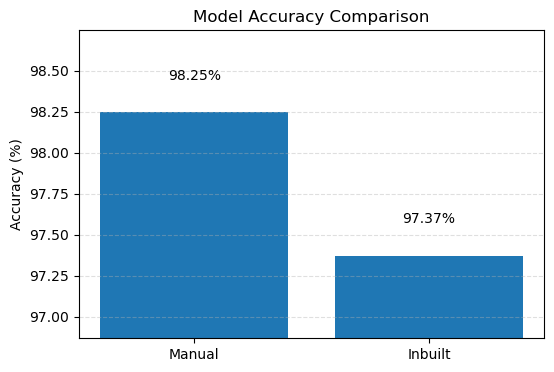

In [41]:
print("Accuracy Difference:  ", acc*100 - acc1*100)
print("Precision Difference: ", pre - pre1)
print("Recall Difference:    ", rec - rec1)
print("F1-score Difference:   ", f1 - f11)

accuracies = [acc*100, acc1*100]
models = ['Manual', 'Inbuilt']

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(min(accuracies)-0.5, max(accuracies)+0.5)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


# Saving Model

In [42]:
import pickle, json

with open ("../models/manual_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved!")

Model saved!
